# LFADS on toy data

A minimal, self-contained tutorial: we **simulate** spiking data from a known
2-dimensional dynamical system, train **LFADS** on it, and check that the model
recovers the underlying dynamics and the single-trial firing rates.

**What LFADS does.** Each trial of spiking data is assumed to be a noisy
observation of a low-dimensional dynamical system. LFADS is a sequential
variational autoencoder:

```
spikes -> encoder RNN -> initial condition g0 -> generator RNN -> factors -> Poisson rates
```

The generator runs *autonomously* from the inferred initial condition, so the
only way to reconstruct a trial well is to put the trial's dynamics into `g0`.
That bottleneck is what turns noisy single-trial spikes into smooth rate
estimates.

**Plan**
1. Simulate a toy dataset
2. Save it in the HDF5 layout `lfads-torch` expects
3. Configure and train an LFADS model
4. Check what the model recovered

> Run this with the `lfads-torch` environment (`pip install -e .` in the repo root).

In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytorch_lightning as pl
import torch
from sklearn.decomposition import PCA
from torch import nn

from lfads_torch.datamodules import BasicDataModule
from lfads_torch.model import LFADS
from lfads_torch.modules import augmentations, priors, recons
from lfads_torch.modules.readin_readout import FanInLinear

pl.seed_everything(0, workers=True)

/home/atleeri/miniforge3/envs/lfads-torch/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/atleeri/miniforge3/envs/lfads-torch/lib/python3.9/site-packages/pytorch_lightning/utilities/imports.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Global seed set to 0


0

## 1. Simulate a toy dataset

The latent state is a 2D decaying rotation. Every trial uses the *same*
dynamics but starts at a different phase, so trials differ only in their
initial condition — exactly the structure LFADS assumes.

A random projection turns the 2D latent into log firing rates for 30 neurons,
and spikes are drawn from a Poisson distribution.

In [2]:
rng = np.random.default_rng(0)

N_TRIALS, N_NEURONS, N_BINS = 500, 30, 50
BIN_SIZE = 0.02  # s, so each trial is 1 s long
FREQ = 2.0  # Hz rotation
TAU = 1.0  # s decay

time = np.arange(N_BINS) * BIN_SIZE
phase = rng.uniform(0, 2 * np.pi, size=N_TRIALS)  # the per-trial initial condition
angle = 2 * np.pi * FREQ * time[None, :] + phase[:, None]
latents = np.stack(
    [np.exp(-time / TAU) * np.cos(angle), np.exp(-time / TAU) * np.sin(angle)], axis=-1
)  # (trials, bins, 2)

# Project latents to log-rates, then sample spikes
proj = rng.normal(0, 1.0, size=(2, N_NEURONS))
baseline = np.log(rng.uniform(5, 25, size=N_NEURONS) * BIN_SIZE)
rates = np.exp(latents @ proj + baseline)  # expected spike count per bin
spikes = rng.poisson(rates).astype(np.float32)

print(f"latents {latents.shape}, rates {rates.shape}, spikes {spikes.shape}")
print(f"mean firing rate: {spikes.mean() / BIN_SIZE:.1f} Hz")

latents (500, 50, 2), rates (500, 50, 30), spikes (500, 50, 30)
mean firing rate: 16.3 Hz


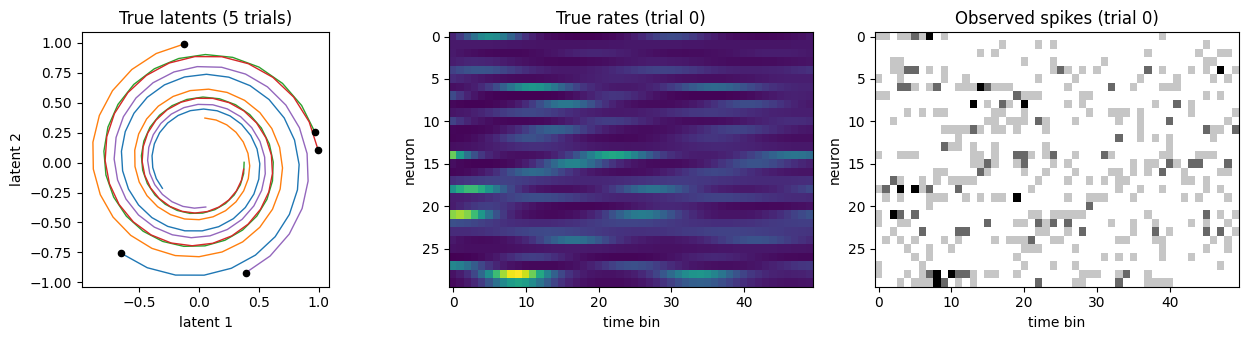

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

axes[0].plot(latents[:5, :, 0].T, latents[:5, :, 1].T, lw=1)
axes[0].scatter(latents[:5, 0, 0], latents[:5, 0, 1], c="k", s=20, zorder=3)
axes[0].set(xlabel="latent 1", ylabel="latent 2", title="True latents (5 trials)")
axes[0].set_aspect("equal")

axes[1].imshow(rates[0].T, aspect="auto", cmap="viridis", interpolation="none")
axes[1].set(xlabel="time bin", ylabel="neuron", title="True rates (trial 0)")

axes[2].imshow(spikes[0].T, aspect="auto", cmap="Greys", interpolation="none")
axes[2].set(xlabel="time bin", ylabel="neuron", title="Observed spikes (trial 0)")

fig.tight_layout()

The rates in the middle are smooth and structured; the spikes on the right —
the only thing LFADS gets to see — look like noise. Recovering the middle
panel from the right one is the whole task.

## 2. Save in the `lfads-torch` HDF5 layout

`BasicDataModule` reads an HDF5 file with one dataset per `{split}_{field}`:

| key | meaning |
| --- | --- |
| `train_encod_data` / `valid_encod_data` | what the **encoder** sees |
| `train_recon_data` / `valid_recon_data` | what the model must **reconstruct** |
| `train_truth` / `valid_truth` *(optional)* | ground-truth rates, used only to log a `valid/r2` metric |
| `conversion_factor` *(optional)* | `truth` is divided by this |

`encod_data` and `recon_data` are separate so you can hold out neurons or
future time steps. We are not doing that here, so both are just the spikes.

In [4]:
N_TRAIN = 400
train, valid = slice(0, N_TRAIN), slice(N_TRAIN, N_TRIALS)

DATA_PATH = "toy_oscillator.h5"
with h5py.File(DATA_PATH, "w") as f:
    f.create_dataset("train_encod_data", data=spikes[train])
    f.create_dataset("train_recon_data", data=spikes[train])
    f.create_dataset("train_truth", data=rates[train])
    f.create_dataset("valid_encod_data", data=spikes[valid])
    f.create_dataset("valid_recon_data", data=spikes[valid])
    f.create_dataset("valid_truth", data=rates[valid])
    f.create_dataset("conversion_factor", data=1.0)

datamodule = BasicDataModule(datafile_pattern=DATA_PATH, batch_size=100)
datamodule.setup()
print(f"{len(datamodule.train_ds[0])} train trials, {len(datamodule.valid_ds[0])} valid trials")

400 train trials, 100 valid trials


## 3. Configure the model

The real repo builds `LFADS` from Hydra configs (see `configs/model/*.yaml`),
but every argument is a plain Python value, so we can pass them directly.

Two choices worth calling out:

- **`co_dim=0` (and `ci_enc_dim=0`, `con_dim=0`) disables the controller.**
  Full LFADS can infer a time-varying input to the generator, which is needed
  when trials are driven by something the initial condition can't explain. Our
  toy dynamics are purely autonomous, so we switch it off. With no controller
  there is no `co` KL term either, hence `priors.Null()`.
- **`CoordinatedDropout`** masks a fraction of the input spikes and blocks the
  gradient on exactly those elements. Without it, an over-parameterised LFADS
  can learn to copy the noisy spikes straight through instead of denoising.

In [5]:
IC_DIM, FAC_DIM = 32, 8

model = LFADS(
    # ---- data shapes ----
    encod_data_dim=N_NEURONS,
    encod_seq_len=N_BINS,
    recon_seq_len=N_BINS,
    ext_input_dim=0,
    ic_enc_seq_len=0,
    # ---- architecture ----
    ic_enc_dim=64,   # encoder RNN that infers the initial condition
    ic_dim=IC_DIM,   # size of the initial condition g0
    gen_dim=64,      # generator RNN
    fac_dim=FAC_DIM, # low-D factors read out to rates
    ci_enc_dim=0,    # } controller disabled: the toy system
    con_dim=0,       # } is autonomous, so there is nothing
    co_dim=0,        # } for a controller to infer
    ci_lag=1,
    readin=nn.ModuleList([nn.Identity()]),
    readout=nn.ModuleList([FanInLinear(FAC_DIM, N_NEURONS)]),
    # ---- likelihood and priors ----
    reconstruction=nn.ModuleList([recons.Poisson()]),
    variational=True,
    ic_prior=priors.MultivariateNormal(mean=0, variance=0.1, shape=IC_DIM),
    co_prior=priors.Null(),
    ic_post_var_min=1e-4,
    # ---- augmentation ----
    train_aug_stack=augmentations.AugmentationStack(
        transforms=[augmentations.CoordinatedDropout(0.3, 0.0, 0)],
        batch_order=[0],
        loss_order=[0],
    ),
    infer_aug_stack=augmentations.AugmentationStack(),
    # ---- optimization ----
    dropout_rate=0.05,
    cell_clip=5.0,
    loss_scale=1e4,
    recon_reduce_mean=True,
    lr_init=4e-3,
    lr_scheduler=False,
    lr_stop=1e-5,
    lr_decay=0.95,
    lr_patience=6,
    lr_adam_beta1=0.9,
    lr_adam_beta2=0.999,
    lr_adam_epsilon=1e-8,
    weight_decay=0.0,
    # ---- regularization (ramped in over the first epochs) ----
    l2_start_epoch=0,
    l2_increase_epoch=40,
    l2_gen_scale=1e-4,
    l2_ic_enc_scale=0.0,
    l2_ci_enc_scale=0.0,
    l2_con_scale=0.0,
    kl_start_epoch=0,
    kl_increase_epoch=40,
    kl_ic_scale=1e-6,
    kl_co_scale=0.0,
)

## 4. Train

A plain PyTorch Lightning `Trainer` — LFADS is a `LightningModule`.

200 epochs takes on the order of 10–20 minutes on CPU. Most of the recovery
happens much earlier — R² against the true rates is already ~0.9 by epoch 100 —
so drop `MAX_EPOCHS` if you just want to see it work.

In [6]:
MAX_EPOCHS = 200

logger = pl.loggers.CSVLogger(save_dir="toy_logs", name="", version="")
trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    logger=logger,
    log_every_n_steps=4,
    enable_model_summary=False,
    gpus=int(torch.cuda.is_available()),
)
trainer.fit(model=model, datamodule=datamodule)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Epoch 199: 100%|██████████| 5/5 [11:58<00:00, 143.71s/it, loss=6.54e+03, v_num=]


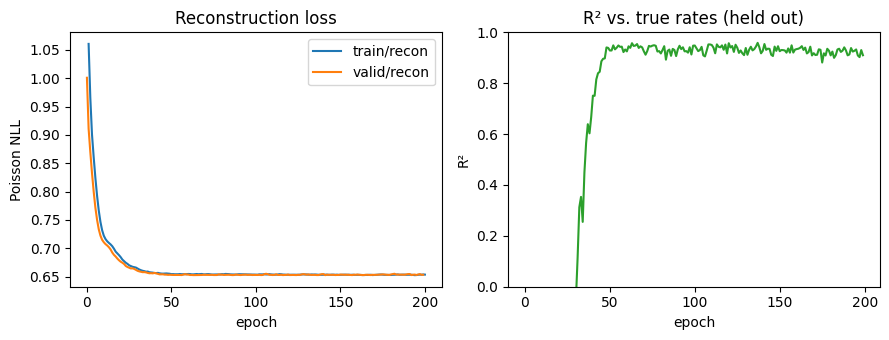

In [7]:
metrics = pd.read_csv("toy_logs/metrics.csv").groupby("epoch").first()

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
metrics[["train/recon", "valid/recon"]].plot(ax=axes[0])
axes[0].set(xlabel="epoch", ylabel="Poisson NLL", title="Reconstruction loss")
metrics["valid/r2"].plot(ax=axes[1], color="C2")
axes[1].set(xlabel="epoch", ylabel="R²", ylim=(0, 1),
            title="R² vs. true rates (held out)")
fig.tight_layout()

## 5. Run the trained model on held-out trials

`predict_step` returns a `SessionOutput` namedtuple with the `factors`, the
initial condition, all the intermediate RNN states, and `output_params` — which
here are already the Poisson means, i.e. expected spike counts per bin, because
`predict_step` calls the reconstruction module's `compute_means`.

With `sample_posteriors=True` each call draws a different sample from the
posterior, so the standard recipe — implemented in the repo as
`lfads_torch.post_run.analysis.run_posterior_sampling` — is to average many
passes. We do that inline here.

In [8]:
model.eval()
valid_batch = datamodule.valid_ds[0].model_tensors

with torch.no_grad():
    samples = [
        model.predict_step({0: (valid_batch, ())}, None, sample_posteriors=True)[0]
        for _ in range(50)
    ]

inferred_rates = torch.stack([s.output_params for s in samples]).mean(0).numpy()
factors = torch.stack([s.factors for s in samples]).mean(0).numpy()

true_rates = rates[valid]
ss_res = ((true_rates - inferred_rates) ** 2).sum()
ss_tot = ((true_rates - true_rates.mean(axis=(0, 1))) ** 2).sum()
print(f"inferred rates {inferred_rates.shape}, factors {factors.shape}")
print(f"R² between inferred and true single-trial rates: {1 - ss_res / ss_tot:.3f}")

inferred rates (100, 50, 30), factors (100, 50, 8)
R² between inferred and true single-trial rates: 0.972


### Did it denoise the single trials?

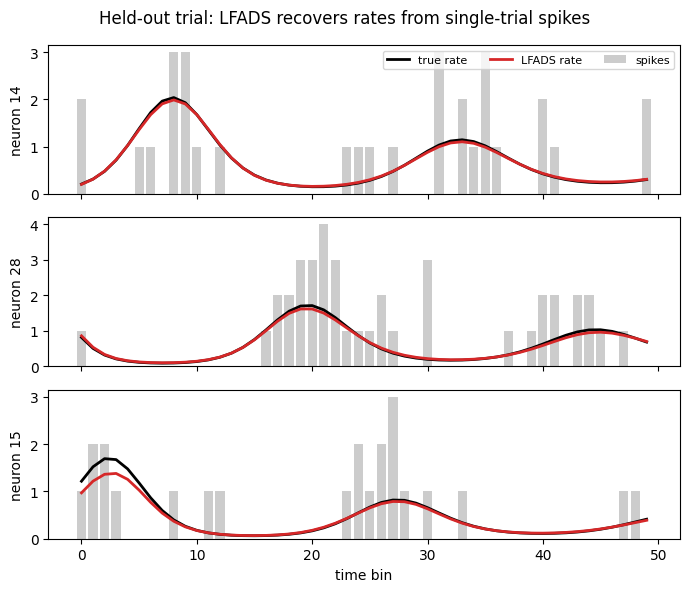

In [9]:
trial = 0
neurons = np.argsort(-true_rates[trial].std(axis=0))[:3]  # 3 most modulated neurons

fig, axes = plt.subplots(3, 1, figsize=(7, 6), sharex=True)
for ax, n in zip(axes, neurons):
    ax.bar(np.arange(N_BINS), spikes[valid][trial, :, n], color="0.8", label="spikes")
    ax.plot(true_rates[trial, :, n], "k", lw=2, label="true rate")
    ax.plot(inferred_rates[trial, :, n], "C3", lw=2, label="LFADS rate")
    ax.set_ylabel(f"neuron {n}")
axes[0].legend(loc="upper right", ncol=3, fontsize=8)
axes[-1].set_xlabel("time bin")
fig.suptitle("Held-out trial: LFADS recovers rates from single-trial spikes")
fig.tight_layout()

### Did it recover the latent dynamics?

The factors live in an 8-dimensional space, but the data was generated from 2
dimensions. Projecting the factors onto their first two principal components
should reveal the rotation — and colouring each trial by its *true* initial
phase should show that neighbouring phases land next to each other.

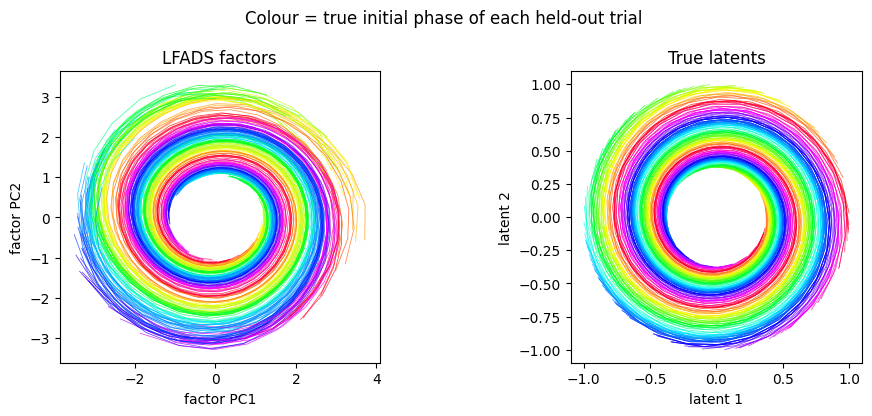

In [10]:
flat = factors.reshape(-1, factors.shape[-1])
pcs = PCA(n_components=2).fit_transform(flat).reshape(*factors.shape[:2], 2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
colors = plt.cm.hsv(phase[valid] / (2 * np.pi))

for i in range(len(pcs)):
    axes[0].plot(pcs[i, :, 0], pcs[i, :, 1], color=colors[i], lw=0.6, alpha=0.7)
axes[0].set(xlabel="factor PC1", ylabel="factor PC2", title="LFADS factors")

for i in range(len(pcs)):
    axes[1].plot(latents[valid][i, :, 0], latents[valid][i, :, 1],
                 color=colors[i], lw=0.6, alpha=0.7)
axes[1].set(xlabel="latent 1", ylabel="latent 2", title="True latents")

for ax in axes:
    ax.set_aspect("equal")
fig.suptitle("Colour = true initial phase of each held-out trial")
fig.tight_layout()

The two panels match up to a rotation/reflection — LFADS has no way to know
the "correct" orientation of a latent space, so recovery up to a linear
transform is the best you can ask for.

## Where to go from here

This notebook wired everything up by hand to keep it readable. Real runs use
the Hydra pipeline instead:

```bash
python scripts/run_single.py                     # one model
python scripts/run_pbt.py                        # population-based HP search
```

Those read `configs/single.yaml`, which composes a `configs/model/*.yaml` and a
`configs/datamodule/*.yaml` holding exactly the arguments we passed above, then
call `lfads_torch.run_model.run_model()` — which trains and automatically runs
`run_posterior_sampling()`, writing an `lfads_output_*.h5` next to your data.

To go further:

- **Turn the controller back on** (`ci_enc_dim`, `con_dim`, `co_dim` > 0) and
  regenerate the toy data with a time-varying input to see LFADS infer it.
- **Hold out neurons or time steps** by making `recon_data` wider or longer
  than `encod_data`; `valid/co_bps` and `valid/fp_bps` then become meaningful.
- **Multiple sessions** — see `tutorials/multisession/`.